# Aqib Ahmed - ViaWay Data Analysis
## GIX Cohort 6, Winter 2023

In [1]:
# Code excerpts from: 
# David Bondesson, OverLordGoldDragon
# Ridge extraction on signals with varying time-frequency characteristics.

%matplotlib notebook

import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ssqueezepy as sp
from ssqueezepy import ssq_cwt, ssq_stft, extract_ridges
from ssqueezepy.visuals import plot, imshow
import math
from tfridge_tracking import ridge_tracking as rt
import sklearn.neighbors

dataset = os.path.abspath("")
print(dataset)

def return_file(file):
    return os.path.join(dataset, file)

%ls # Show current directory's contents.

/Users/aqibahmed/Desktop/ViaWay
Acceleration without g 2023-02-27 09-51-54.xls
Aqib Ahmed - ViaWay Data Analysis.ipynb
bridge_data_ground_truth.csv
bridge_data_ground_truth_2.csv
bridge_data_vibrations.csv
bridge_ground_truth_phone.csv
bridge_ground_truth_vibrations.csv
bridge_vibrations_phone.csv
cad/
data/
electronics/
sep_accel_data.csv
signal_processing_results/
tfridge_tracking/


In [2]:
def tf_transforms(x, t, wavelet='morlet', window=None, padtype='wrap',
                  penalty=.5, n_ridges=2, cwt_bw=15, stft_bw=15,
                  ssq_cwt_bw=4, ssq_stft_bw=4):
    kw_cwt  = dict(t=t, padtype=padtype)
    kw_stft = dict(fs=1/(t[1] - t[0]), padtype=padtype, flipud=1)
    Twx, Wx, ssq_freqs_c, scales, *_ = ssq_cwt(x,  wavelet, **kw_cwt)
    Tsx, Sx, ssq_freqs_s, Sfs, *_    = ssq_stft(x, window,  **kw_stft)
    Sx, Sfs = Sx[::-1], Sfs[::-1]

    ckw = dict(penalty=penalty, n_ridges=n_ridges, transform='cwt')
    skw = dict(penalty=penalty, n_ridges=n_ridges, transform='stft')
    cwt_ridges      = extract_ridges(Wx,  scales,      bw=cwt_bw,      **ckw)
    ssq_cwt_ridges  = extract_ridges(Twx, ssq_freqs_c, bw=ssq_cwt_bw,  **ckw)
    stft_ridges     = extract_ridges(Sx,  Sfs,         bw=stft_bw,     **skw)
    ssq_stft_ridges = extract_ridges(Tsx, ssq_freqs_s, bw=ssq_stft_bw, **skw)

    viz(x, Wx,  cwt_ridges,      scales,      ssq=0, transform='cwt',  show_x=1)
    viz(x, Twx, ssq_cwt_ridges,  ssq_freqs_c, ssq=1, transform='cwt',  show_x=0)
    viz(x, Sx,  stft_ridges,     Sfs,         ssq=0, transform='stft', show_x=0)
    viz(x, Tsx, ssq_stft_ridges, ssq_freqs_s, ssq=1, transform='stft', show_x=0)

In [3]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / N

In [4]:
# TODO: Function to downsample signal to 100 Hz.

In [5]:
# read_file = pd.read_excel (r'./Acceleration without g 2023-02-27 09-51-54.xls')
# read_file.to_csv (r'./sep_accel_data.csv', index = None, header=True)

# accel_data = pd.read_csv('./bridge_data_ground_truth.csv')
accel_data = pd.read_csv('./sep_accel_data.csv')
accel_data

,Time (s),Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.016863,-0.150541,-0.096553,-0.034044,0.182055
1,0.026832,-0.032855,-0.041175,-1.076800,1.078088
2,0.036800,0.023795,0.167503,-0.340362,0.380091
3,0.046769,0.106121,0.280100,0.622278,0.690614
4,0.056738,0.105554,0.100910,0.419632,0.444315
...,...,...,...,...,...
761,7.603048,0.018594,-0.702750,0.780883,1.050705
762,7.613017,0.818111,-0.615654,-1.387412,1.724311
763,7.622986,0.901306,-0.332968,-3.102196,3.247590
764,7.632955,0.617755,-0.139683,-0.641957,0.901799


In [6]:
# Extract Linear Acceleration z (m/s^2)column:
z_acc = accel_data["Linear Acceleration z (m/s^2)"]
z_acc


0     -0.034044
1     -1.076800
2     -0.340362
3      0.622278
4      0.419632
         ...   
761    0.780883
762   -1.387412
763   -3.102196
764   -0.641957
765    2.352199
Name: Linear Acceleration z (m/s^2), Length: 766, dtype: float64

In [7]:
# TODO: 
# 0. Resample date at 100 Hz. --> PENDING
# 1. Morlet wavelet transform --> DONE
# 2. Frequency Ridge Extraction --> DONE
# 3. Histogram  of extracted ridges --> DONE
# 4. Kernel density estimation on histogram from (3) --> DONE
# 5. 


# Begin by visualizing the z-axis acceleration:
# z_acc = sample_df[["Timestamp", "accelZ"]]
# z_acc.plot(x = "Timestamp", y = "accelZ", kind = "line", figsize=(9, 8), xlabel = None)
# plt.show()

def get_bridge_coordinates(lat, lon):
        lat1 = lat[0]
        lon1 = lon[0]
        distances = []
        distances.append(0)
        R = 6371000                               # radius of Earth in meters
        
        for i in range(1, len(lat)):
            lat2 = lat[i]
            lon2 = lon[i]
            
            phi_1 = math.radians(lat1)
            phi_2 = math.radians(lat2)
            

            delta_phi = math.radians(lat2 - lat1)
            delta_lambda = math.radians(lon2-  lon1)
 
            a = math.sin(delta_phi / 2.0)**2 + math.cos(phi_1) * math.cos(phi_2) * math.sin(delta_lambda / 2.0)**2
            c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
        
            meters = R * c                         # output distance in meters
            distances.append(meters)
            lat1 = lat2
            lon1 = lon2
#         self.km=self.meters/1000.0              # output distance in kilometers
#         self.miles=self.meters*0.000621371      # output distance in miles
#         self.feet=self.miles*5280               # output distance in feet
        return distances

# coordinates = sample_df[["Lat", "Long"]]
# # display(coordinates)

# latitudes = np.array(coordinates[["Lat"]])
# longitudes = np.array(coordinates[["Long"]])

# distances = get_bridge_coordinates(latitudes, longitudes)
# print(distances)
# plt.figure()
# plt.plot(distances)
# plt.show()
# print(len(distances))

In [8]:
z_acc

0     -0.034044
1     -1.076800
2     -0.340362
3      0.622278
4      0.419632
         ...   
761    0.780883
762   -1.387412
763   -3.102196
764   -0.641957
765    2.352199
Name: Linear Acceleration z (m/s^2), Length: 766, dtype: float64

In [9]:
def viz(x, Tx, Wx):
    plt.title("Synchrosqueezed Wavelet Transform [Morlet Window] Assumed Ground Truth")
    plt.xlabel("Time [samples]")
    plt.ylabel("Time Scales [1/Hz]")
    
    plt.imshow(np.abs(Tx), aspect='auto', cmap=plt.cm.nipy_spectral_r)
#     plt.show()
#     plt.imshow(np.abs(Tx), aspect='auto', vmin=0, vmax=.2, cmap = plt.cm.nipy_spectral_r)
    plt.show()

#%%# Define signal ####################################

# N = 2048
# t = np.linspace(0, 10, N, endpoint=False)
# xo = np.cos(2 * np.pi * 2 * (np.exp(t / 2.2) - 1))
# xo += xo[::-1]  # add self reflected
# x = xo + np.sqrt(2) * np.random.randn(N)  # add noise

# plt.plot(xo); plt.show()
# plt.plot(x);  plt.show()

# #%%# CWT + SSQ CWT ####################################
# Twxo, Wxo, *_ = ssq_cwt(xo)
# viz(xo, Twxo, Wxo)

# Twx, Wx, *_ = ssq_cwt(x)
# viz(x, Twx, Wx)

# #%%# STFT + SSQ STFT ##################################
# Tsxo, Sxo, *_ = ssq_stft(xo)
# viz(xo, np.flipud(Tsxo), np.flipud(Sxo))

# Tsx, Sx, *_ = ssq_stft(x)
# viz(x, np.flipud(Tsx), np.flipud(Sx))

In [10]:
# z_acc_arr = np.array(z_acc["accelZ"])
# z_accel = np.array(z_acc)
t = np.linspace(0, 10, len(z_acc), endpoint=False)

# plt.figure()
# plt.plot(t, z_accel)
# plt.show()

# print(len(z_accel))
z_acc.shape


(766,)

<IPython.core.display.Javascript object>


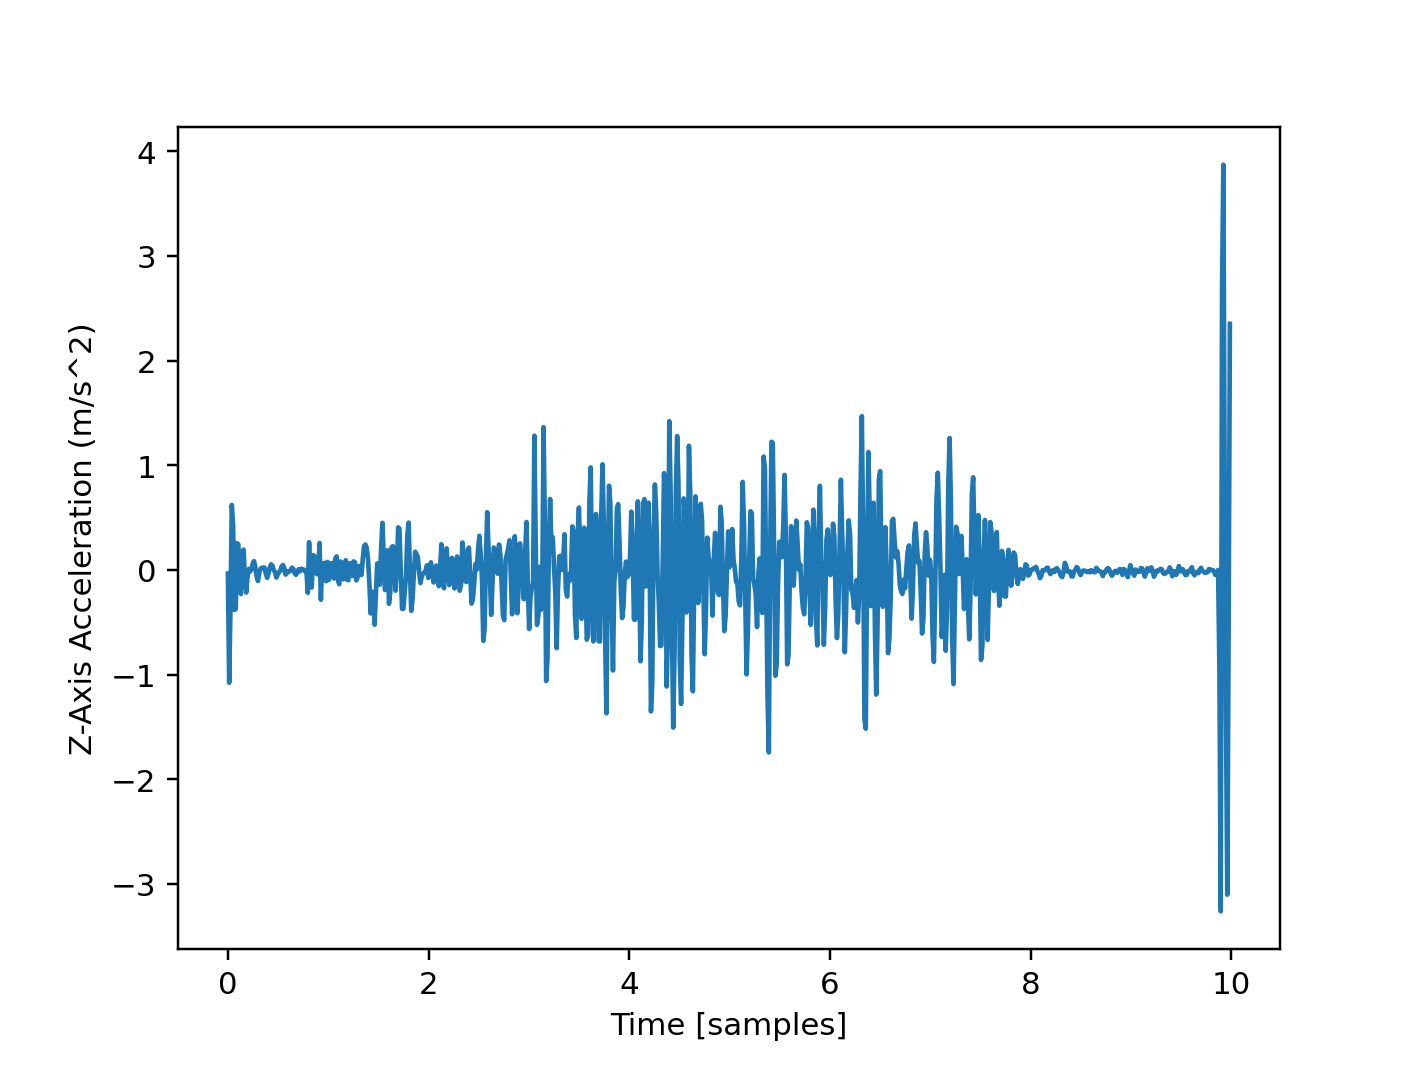

In [11]:
plt.figure()
plt.plot(t, z_acc)
plt.ylabel("Z-Axis Acceleration (m/s^2)")
plt.xlabel("Time [samples]")
plt.show()

In [12]:
z_acc = np.array(z_acc).flatten()

<IPython.core.display.Javascript object>


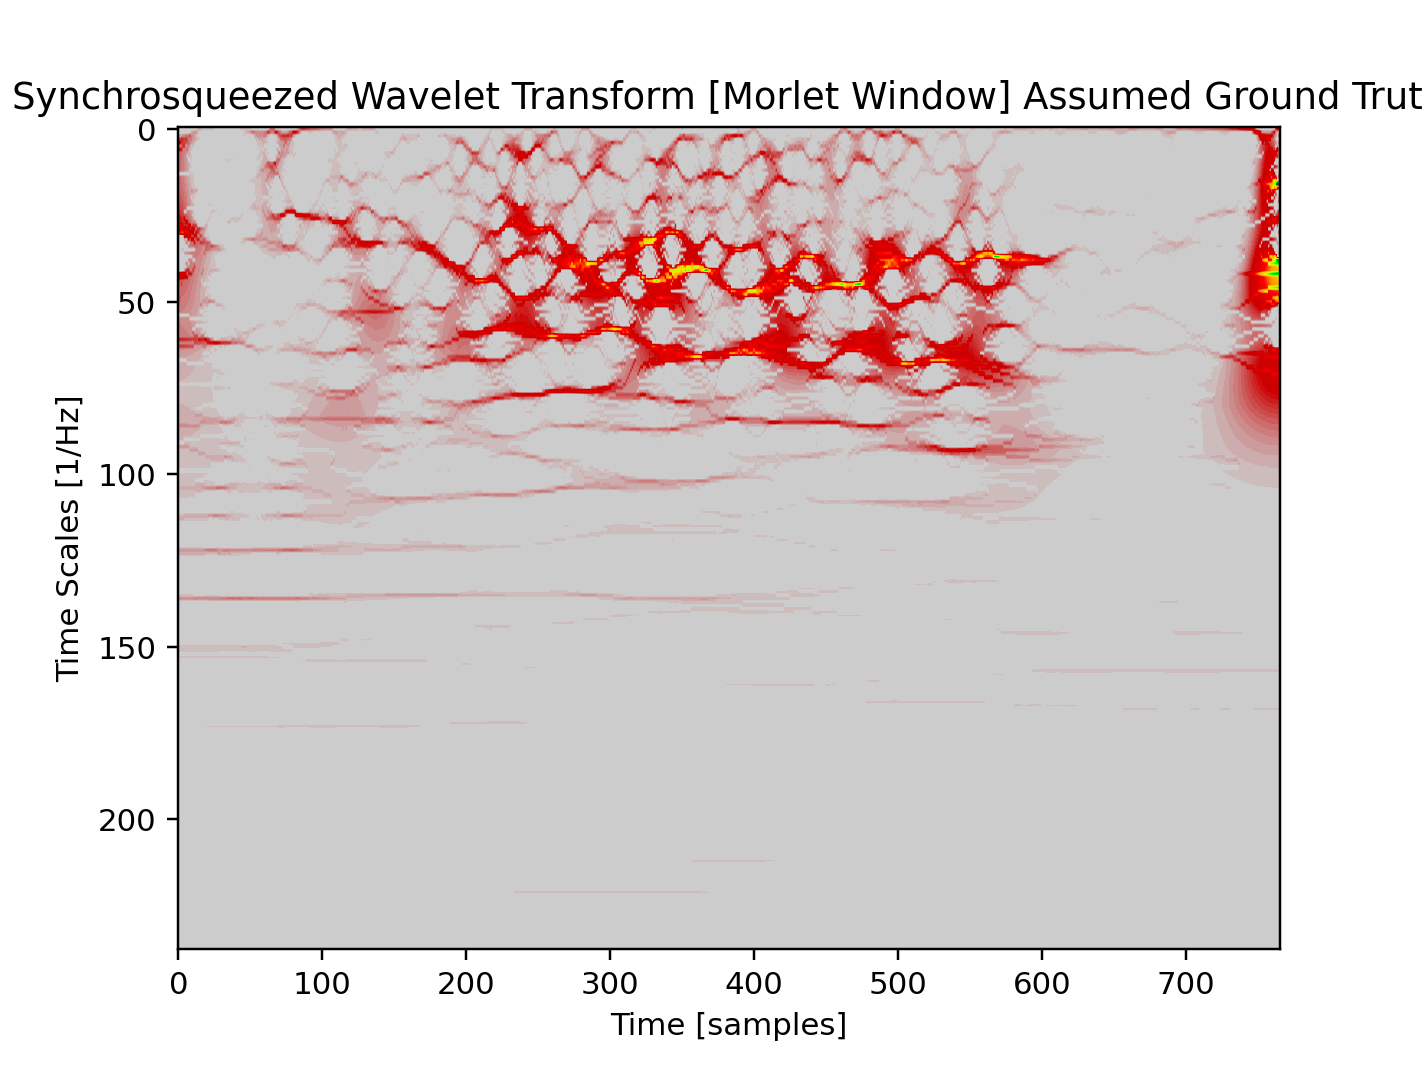

In [13]:
# Here, x will be the original accel_z signal, 
N, f = len(z_acc), 0.5
padtype = 'wrap'
penalty = 20

t  = np.linspace(0, 10, N, endpoint=True)

# tf_transforms(z_acc, t, n_ridges=3, padtype=padtype, stft_bw=4, ssq_stft_bw=4,
#               penalty=penalty)

# TODO: 
Twz, Wz, ssq_freqs_c, scales, *_ = ssq_cwt(z_acc, 'morlet')
plt.figure()
viz(z_acc, Twz, Wz)
plt.show()

In [14]:
# Extract z_accel data as array
# plt.figure()

# print(len(z_acc_arr), lSen(t))
# print(z_acc_arr)
# print(t)

ssq_freqs_c

# Twz, Wz, *_ = ssq_cwt(z_accel)
# viz(z_accel, Twz, Wz)

array([0.5       , 0.48935529, 0.4789372 , 0.46874091, 0.45876169,
       0.44899492, 0.43943608, 0.43008074, 0.42092457, 0.41196333,
       0.40319287, 0.39460913, 0.38620813, 0.37798599, 0.36993889,
       0.3620631 , 0.35435499, 0.34681098, 0.33942758, 0.33220136,
       0.32512899, 0.31820718, 0.31143273, 0.30480251, 0.29831345,
       0.29196253, 0.28574681, 0.27966343, 0.27370956, 0.26788244,
       0.26217938, 0.25659774, 0.25113492, 0.2457884 , 0.24055571,
       0.23543442, 0.23042216, 0.2255166 , 0.22071549, 0.21601658,
       0.21141772, 0.20691676, 0.20251162, 0.19820026, 0.1939807 ,
       0.18985096, 0.18580914, 0.18185338, 0.17798182, 0.17419269,
       0.17048423, 0.16685472, 0.16330248, 0.15982587, 0.15642327,
       0.15309311, 0.14983385, 0.14664397, 0.14352201, 0.14046651,
       0.13747606, 0.13454927, 0.1316848 , 0.1288813 , 0.12613749,
       0.1234521 , 0.12082388, 0.11825161, 0.1157341 , 0.11327019,
       0.11085873, 0.10849861, 0.10618874, 0.10392805, 0.10171

In [15]:
Twz

array([[ 6.9452421e-05+8.0692952e-10j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j, ...,
         8.5081831e-03-1.4325883e-03j, -8.4916065e-03+1.4912691e-03j,
         5.9999805e-03+8.6460750e-05j],
       [ 0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j, ...,
         1.2170215e-03-1.3047947e-03j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j],
       [ 1.7824883e-03-3.3584693e-05j, -1.7506061e-03+2.8719928e-04j,
         1.6585788e-03-5.2144961e-04j, ...,
         0.0000000e+00+0.0000000e+00j,  3.0949095e-03-1.4655087e-04j,
         0.0000000e+00+0.0000000e+00j],
       ...,
       [ 0.0000000e+00+0.0000000e+00j,  0.0000000e+00+0.0000000e+00j,
         0.0000000e+00+0.0000000e+00j, ...,
        -1.1572209e-05+2.0898210e-06j, -1.1581767e-05+2.0047585e-06j,
        -1.1590671e-05+1.9196671e-06j],
       [-6.8598279e-06-4.7107555e-06j, -6.8379877e-06-4.7651693e-06j,
        -6.8156983e-06

In [16]:
# Twz, Wz, *_ = ssq_cwt(z_accel)
# viz(z_accel, Twz, Wz)

In [17]:
Twz.shape

(238, 766)

In [18]:
Wz.shape

(238, 766)

In [19]:
# Extract from sampled dataset:
# plt.figure()
# plt.plot(t, np.transpose(Twz))
# plt.show()

In [20]:
# Frequency ridge detection
# scales = np.exp(np.linspace(np.log(1.51),np.log(622.207),nbr_scales))
# cwtmatr, freqs = pywt.cwt(signal,scales,'cmor2.0-1.0')
# nbr_scales=269
# scales=np.exp(np.linspace(np.log(1.51),np.log(622.207),nbr_scales))
# penalty = 2.0
# cwtmatr, freqs = pywt.cwt(sweep_sig,scales,'cmor2.0-1.5')

# # CWT example
# Energy,ridge_idx, _ = rt.extract_fridges(cwtmatr, scales, penalty, num_ridges = 50, BW = 25)



In [21]:
def visualize(x, Tf, ridge_idxs, yticks = None, ssq = False, transform = 'cwt', show_x = True):
    if show_x:
        plot(x, title="x(t)", show = 1,
             xlabel="Time [samples]", ylabel="Signal Amplitude [A.U.]")

    ylabel = ("Frequency scales [1/Hz]" if (transform == 'cwt' and not ssq) else
              "Frequencies [Hz]")
    title = "abs({}{}) w/ ridge_idxs for Assumed Ground Truth".format("SSQ_" if ssq else "",
                                             transform.upper())

    ikw = dict(abs = 1, cmap = plt.cm.nipy_spectral_r, yticks = yticks, title = title)
    pkw = dict(linestyle = '--', color = 'k', xlabel = "Time [samples]", ylabel = ylabel,
               xlims=(0, Tf.shape[1]))

    imshow(Tf, **ikw, show = 0)
    plot(ridge_idxs, **pkw, show = 1)

<IPython.core.display.Javascript object>


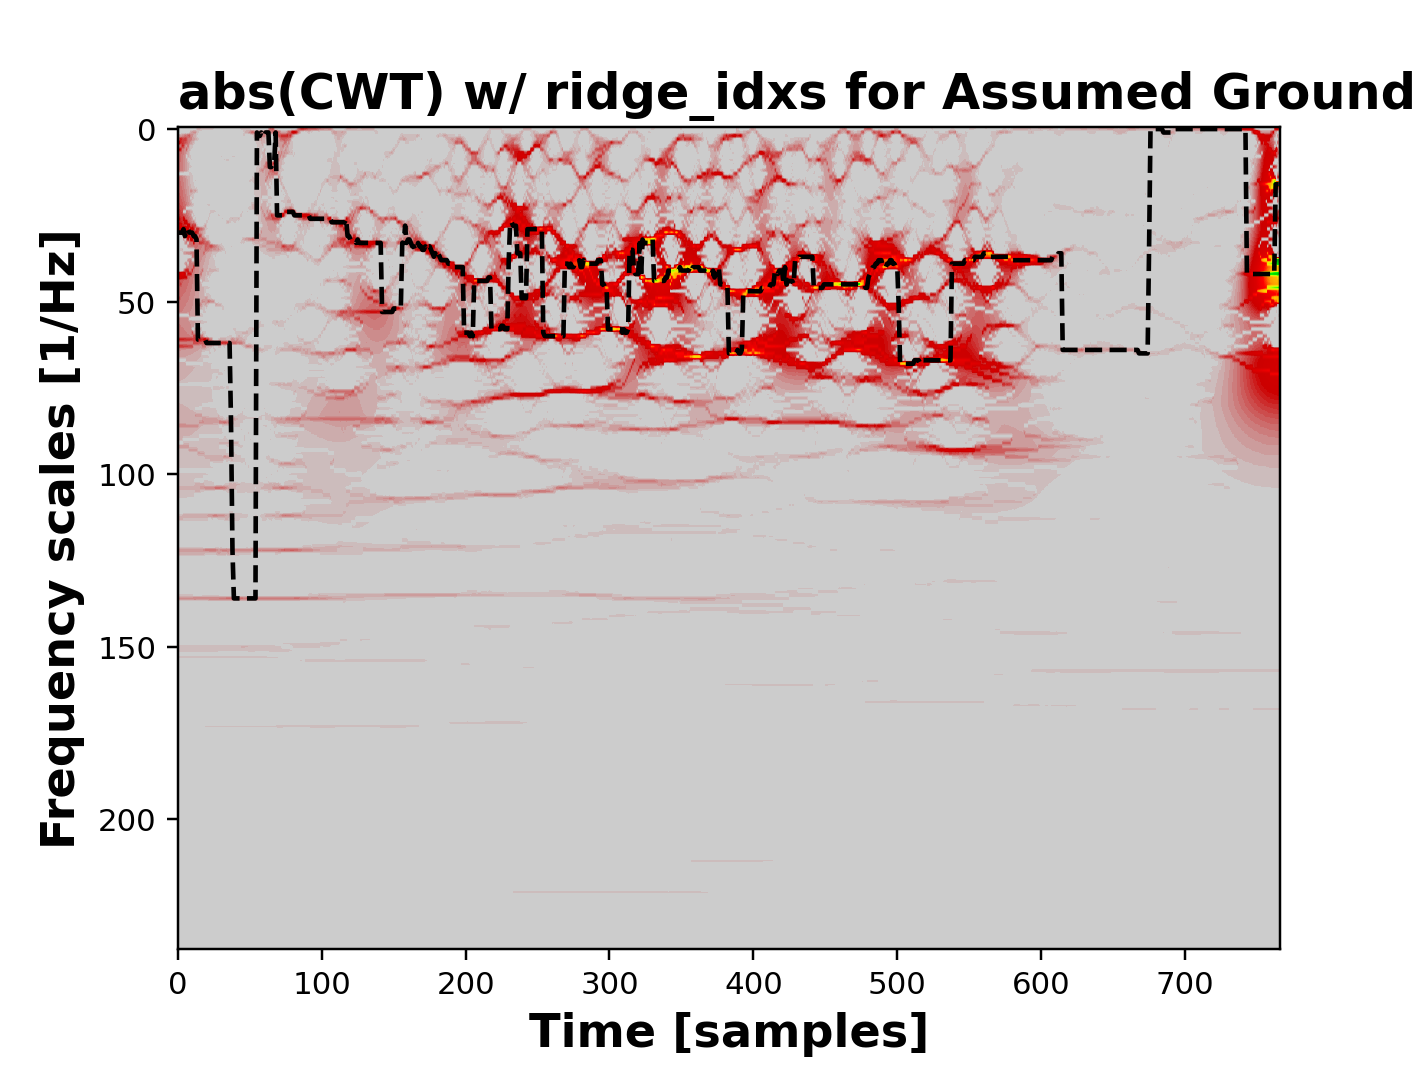

In [22]:
# plt.figure()
# visualize(z_acc, Twz, ridge_idx)
# viz(z_acc, Twz, ridge_idx)

# Ridge Detection: 
ssq_cwt_ridge_idxs = extract_ridges(Twz, ssq_freqs_c, bw = 2, transform = 'cwt', n_ridges = 5)

plt.figure()
visualize([], Twz, [x[0] for x in ssq_cwt_ridge_idxs])

In [23]:
ssq_cwt_ridge_idxs.shape

(766, 5)

In [24]:
ssq_cwt_ridges_first = np.array([x[1] for x in ssq_cwt_ridge_idxs])
ssq_cwt_ridges_first

array([ 42,  42,  42,  42,  31,  27,  31,  31,  42,  32,  32,  33,  28,
        29,  32,  33,  33,  33,  33,  34,  33,  33,  34,  34,  34,  50,
       104, 104, 104, 104, 104, 104,  85,  85,  85,  85,  85,  62,  62,
        62,  62,  62,  62,  62,  62,  62,  62,  63,  63,  63,  32,   1,
         1,   1,   1,   1,  13,  12,  12,  12,  11,   1,   1,  11,  26,
        25,  12,   1,   1,   1,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   1,   1,   1,   1,   1,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  38,  65,  84,  84,  84,  84,
        84,  84,  76,  76,  65,  34,  34,  32,  32,  32,  32,  29,  29,
        30,  33,  33,  64,  64,  64,  64,  53,  53,  53,  53,  53,  53,
        53,  53,  53,  53,  53,  53,  53,  53,  53,  53,  53,  53,  33,
        33,  26,  26,  26,  26,  26,  26,  26,  26,  26,  27,  27,  33,
        28,  28,  33,  29,  29,  34,  28,  31,  30,  32,  32,  35,  51,
        69,  69,  69,  69,  69,  69,  63,  63,  63,  63,  52,  5

In [25]:
# Here, x will be the original accel_z signal, 
N, f = len(z_acc), 0.5
padtype = 'wrap'
penalty = 20

# t  = np.linspace(0, 10, N, endpoint=True)

# tf_transforms(z_acc, t, n_ridges=3, padtype=padtype, stft_bw=4, ssq_stft_bw=4,
#               penalty=penalty)

# TODO: 
# Twx, Wx, ssq_freqs_c, scales, *_ = ssq_cwt(z_accel, 'morlet')

# viz(z_accel, Twx, Wx)

<IPython.core.display.Javascript object>


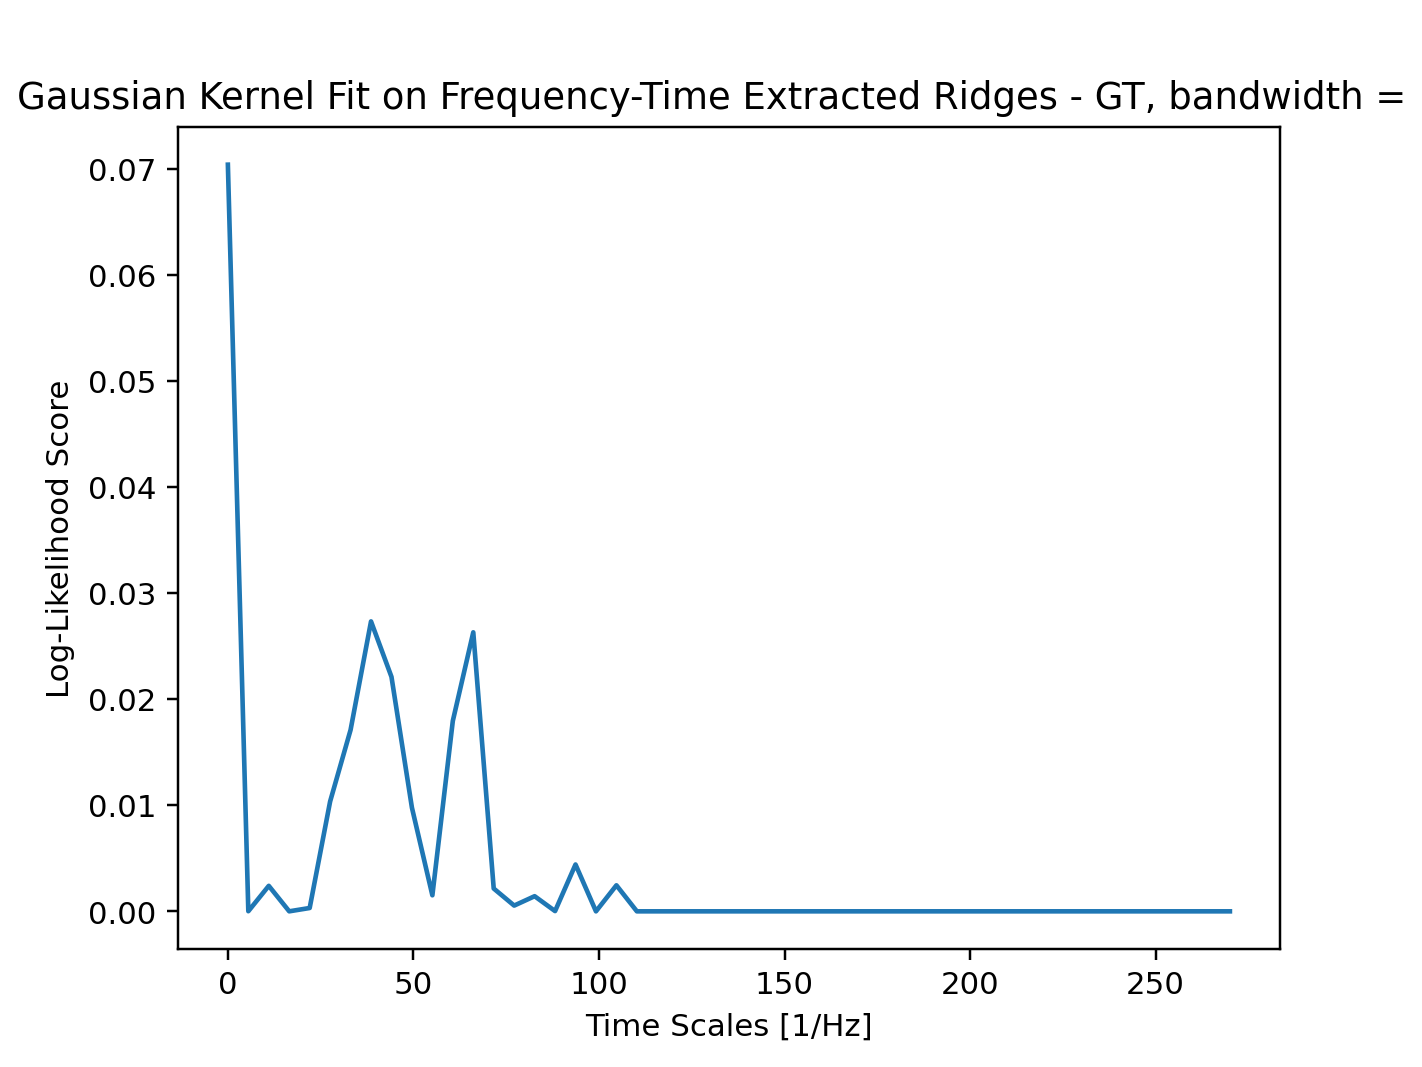

In [26]:
# TODO: Produce histogram for frequency - count
# Gaussian KDE

kde_ridge_data = ssq_cwt_ridges_first.reshape(-1, 1)
N = len(kde_ridge_data)
x_plot = np.linspace(0, 270)
# x_plot = [1/x if x != 0 else 0 for x in x_plot]
# X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]
kde = sklearn.neighbors.KernelDensity(kernel = "gaussian", bandwidth = 1).fit(kde_ridge_data)
log_dens = kde.score_samples(np.array(x_plot).reshape(-1, 1))

plt.figure()
# plt.hist(np.exp(log_dens), fc='gray', histtype='stepfilled', alpha=1)
plt.plot(x_plot, np.exp(log_dens))
plt.title("Gaussian Kernel Fit on Frequency-Time Extracted Ridges - GT, bandwidth = 1")
plt.xlabel("Time Scales [1/Hz]")
plt.ylabel("Log-Likelihood Score")
plt.show()

In [27]:
# TODO: 
# ssq_cwt_ridges  = extract_ridges(Twz, ssq_freqs_c, bw = 4, transform = 'cwt', n_ridges = 50)
# visualize(z_accel, Twz, ssq_cwt_ridges,  ssq_freqs_c, ssq=1, transform='cwt',  show_x=0)

# TODO: 
# Function to extract top n maxima from Extracted Ridge Kernel Density Estimate

def get_max_log_scores(x, n):
    # Base case: len(x) == 0:
    if len(x) == 0:
        return []
    elif len(x) < n:
        return sorted(x, reverse = True)
    else:
        return sorted(x, reverse = True)[:n]
    
get_max_log_scores(np.exp(log_dens), 3)

[0.07041428954585159, 0.027341072899696884, 0.026312844703355577]